In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 58.5 MB/s eta 0:00:00


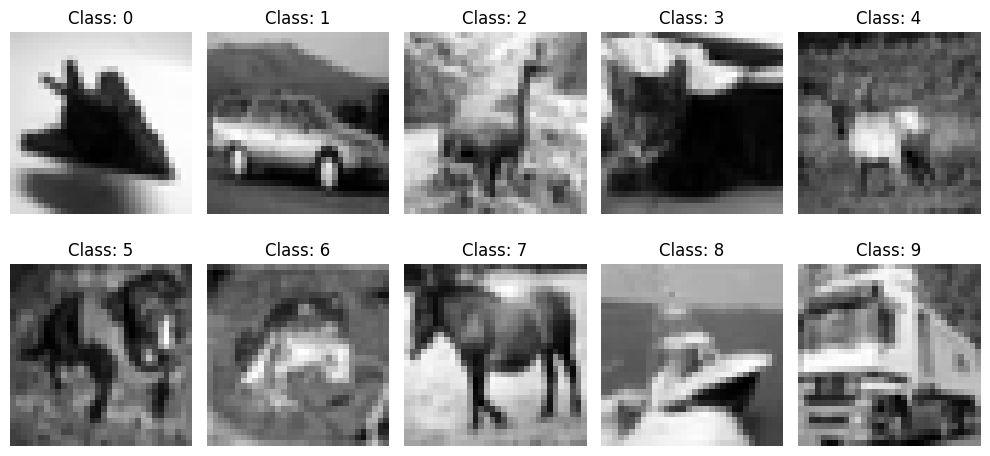

In [12]:
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
from torchvision import transforms
import torch
#Showing sample images

dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)

# Store one image per class
images = [None] * 10
found = [False] * 10

for img, label in dataset:
    if not found[label]:
        images[label] = (img, label)
        found[label] = True
    if all(found):
        break

# Plot
plt.figure(figsize=(10, 5))
for i, (img, label) in enumerate(images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')  # Grayscale image
    plt.title(f"Class: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [13]:
# quantum_cifar_binary_classifier.py
import pennylane as qml
from pennylane import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Set seed
torch.manual_seed(0)
np.random.seed(0)

# 1. Load CIFAR-10
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((8, 8)),
    transforms.ToTensor()
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)


def filter_classes(dataset, class0=0, class1=1, max_samples=None):
    x, y = [], []
    for img, label in dataset:
        if label == class0 or label == class1:
            x.append(img.view(-1))
            y.append(0 if label == class0 else 1)
        if max_samples and len(x) >= max_samples:
            break
    return torch.stack(x), torch.tensor(y)

#  Limit training and testing to small sizes
x_train, y_train = filter_classes(trainset, max_samples=1000,class0=0,class1=5)
x_test, y_test = filter_classes(testset, max_samples=200)

# Normalize
x_train = (x_train - x_train.mean()) / x_train.std()
x_test = (x_test - x_test.mean()) / x_test.std()


def avgpool_features(x, out_features=8):
    x = x.view(-1, 1, 8, 8)
    x = F.avg_pool2d(x, kernel_size=2)  # (N, 1, 4, 4)
    x = x.view(x.shape[0], -1)          # (N, 16)
    if x.shape[1] < out_features:
        padding = torch.zeros((x.shape[0], out_features - x.shape[1]))
        x = torch.cat([x, padding], dim=1)
    elif x.shape[1] > out_features:
        x = x[:, :out_features]
    return x

x_train = avgpool_features(x_train, out_features=8)
x_test = avgpool_features(x_test, out_features=8)
# Create small validation set from training
val_size = 150
train_size = len(x_train) - val_size

train_data = TensorDataset(x_train, y_train)
train_set, val_set = random_split(train_data, [train_size, val_size])

# Use batch size = full size since dataset is small
train_loader = DataLoader(train_set, batch_size=train_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=val_size)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=len(x_test))


In [14]:
train_loader.dataset[0]

(tensor([0.4043, 0.4920, 0.2751, 0.2243, 0.2335, 1.1476, 0.2151, 0.2381]),
 tensor(0))

In [16]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 8
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def single_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)

    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)

    for i in range(n_qubits - 1):
        qml.IsingXX(weights[1, i], wires=[i, i + 1])

    for i in range(n_qubits):
        qml.RZ(weights[2, i], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class QuantumLayer(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(3, n_qubits, dtype=torch.float32))

    def forward(self, x):
        x = x.float()
        if len(x.shape) == 1:
            x = x.unsqueeze(0)

        outputs = []
        for i in range(x.shape[0]):
            out = single_circuit(x[i], self.weights)
            outputs.append(torch.stack(out))

        return torch.stack(outputs)

class QuantumClassifier(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.quantum = QuantumLayer(n_qubits)
        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = self.quantum(x)
        return self.classical(x)


model = QuantumClassifier(n_qubits).float()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()


def train(model, loader, val_loader, epochs=25):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in loader:

            xb = xb.float()
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.float()
                out = model(xb)
                preds = out.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        print(f"Epoch {epoch+1:2d} | Loss: {total_loss:.4f} | Val Accuracy: {correct/total:.4f}")

# Run training
train(model, train_loader, val_loader)

Epoch  1 | Loss: 0.7008 | Val Accuracy: 0.4733
Epoch  2 | Loss: 0.6963 | Val Accuracy: 0.5067
Epoch  3 | Loss: 0.6923 | Val Accuracy: 0.5333
Epoch  4 | Loss: 0.6887 | Val Accuracy: 0.5667
Epoch  5 | Loss: 0.6854 | Val Accuracy: 0.6000
Epoch  6 | Loss: 0.6823 | Val Accuracy: 0.6133
Epoch  7 | Loss: 0.6793 | Val Accuracy: 0.6200
Epoch  8 | Loss: 0.6763 | Val Accuracy: 0.6067
Epoch  9 | Loss: 0.6734 | Val Accuracy: 0.6067
Epoch 10 | Loss: 0.6703 | Val Accuracy: 0.6200
Epoch 11 | Loss: 0.6672 | Val Accuracy: 0.6133
Epoch 12 | Loss: 0.6641 | Val Accuracy: 0.6000
Epoch 13 | Loss: 0.6609 | Val Accuracy: 0.6000
Epoch 14 | Loss: 0.6576 | Val Accuracy: 0.6000
Epoch 15 | Loss: 0.6544 | Val Accuracy: 0.6067
Epoch 16 | Loss: 0.6511 | Val Accuracy: 0.6067
Epoch 17 | Loss: 0.6476 | Val Accuracy: 0.6133
Epoch 18 | Loss: 0.6439 | Val Accuracy: 0.6200
Epoch 19 | Loss: 0.6402 | Val Accuracy: 0.6200
Epoch 20 | Loss: 0.6364 | Val Accuracy: 0.6000
Epoch 21 | Loss: 0.6325 | Val Accuracy: 0.5933
Epoch 22 | Lo

In [17]:
train(model, train_loader, val_loader)

Epoch  1 | Loss: 0.6122 | Val Accuracy: 0.6267
Epoch  2 | Loss: 0.6078 | Val Accuracy: 0.6267
Epoch  3 | Loss: 0.6032 | Val Accuracy: 0.6267
Epoch  4 | Loss: 0.5988 | Val Accuracy: 0.6267
Epoch  5 | Loss: 0.5944 | Val Accuracy: 0.6200
Epoch  6 | Loss: 0.5902 | Val Accuracy: 0.6267
Epoch  7 | Loss: 0.5862 | Val Accuracy: 0.6400
Epoch  8 | Loss: 0.5824 | Val Accuracy: 0.6400
Epoch  9 | Loss: 0.5787 | Val Accuracy: 0.6267
Epoch 10 | Loss: 0.5753 | Val Accuracy: 0.6267
Epoch 11 | Loss: 0.5719 | Val Accuracy: 0.6267
Epoch 12 | Loss: 0.5686 | Val Accuracy: 0.6200
Epoch 13 | Loss: 0.5652 | Val Accuracy: 0.6133
Epoch 14 | Loss: 0.5617 | Val Accuracy: 0.6200
Epoch 15 | Loss: 0.5582 | Val Accuracy: 0.6267
Epoch 16 | Loss: 0.5547 | Val Accuracy: 0.6333
Epoch 17 | Loss: 0.5510 | Val Accuracy: 0.6400
Epoch 18 | Loss: 0.5474 | Val Accuracy: 0.6333
Epoch 19 | Loss: 0.5439 | Val Accuracy: 0.6333
Epoch 20 | Loss: 0.5405 | Val Accuracy: 0.6467
Epoch 21 | Loss: 0.5372 | Val Accuracy: 0.6533
Epoch 22 | Lo


 Test Accuracy: 0.6600


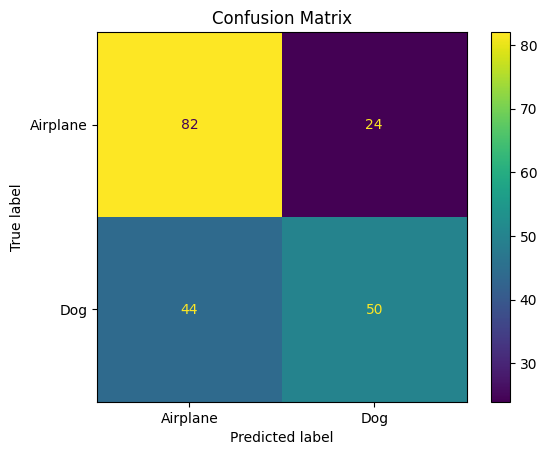

In [18]:
# 5. Evaluate on Test Set
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.float()
        if len(xb.shape) == 3:  # If input is image data (C, H, W)
            xb = xb.flatten(start_dim=1)  # Flatten to (batch_size, n_features)

        out = model(xb)
        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())  # Move to CPU for sklearn
        all_true.append(yb.cpu())

# Concatenate results
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

# Calculate metrics
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy: {acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Airplane", "Dog"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()



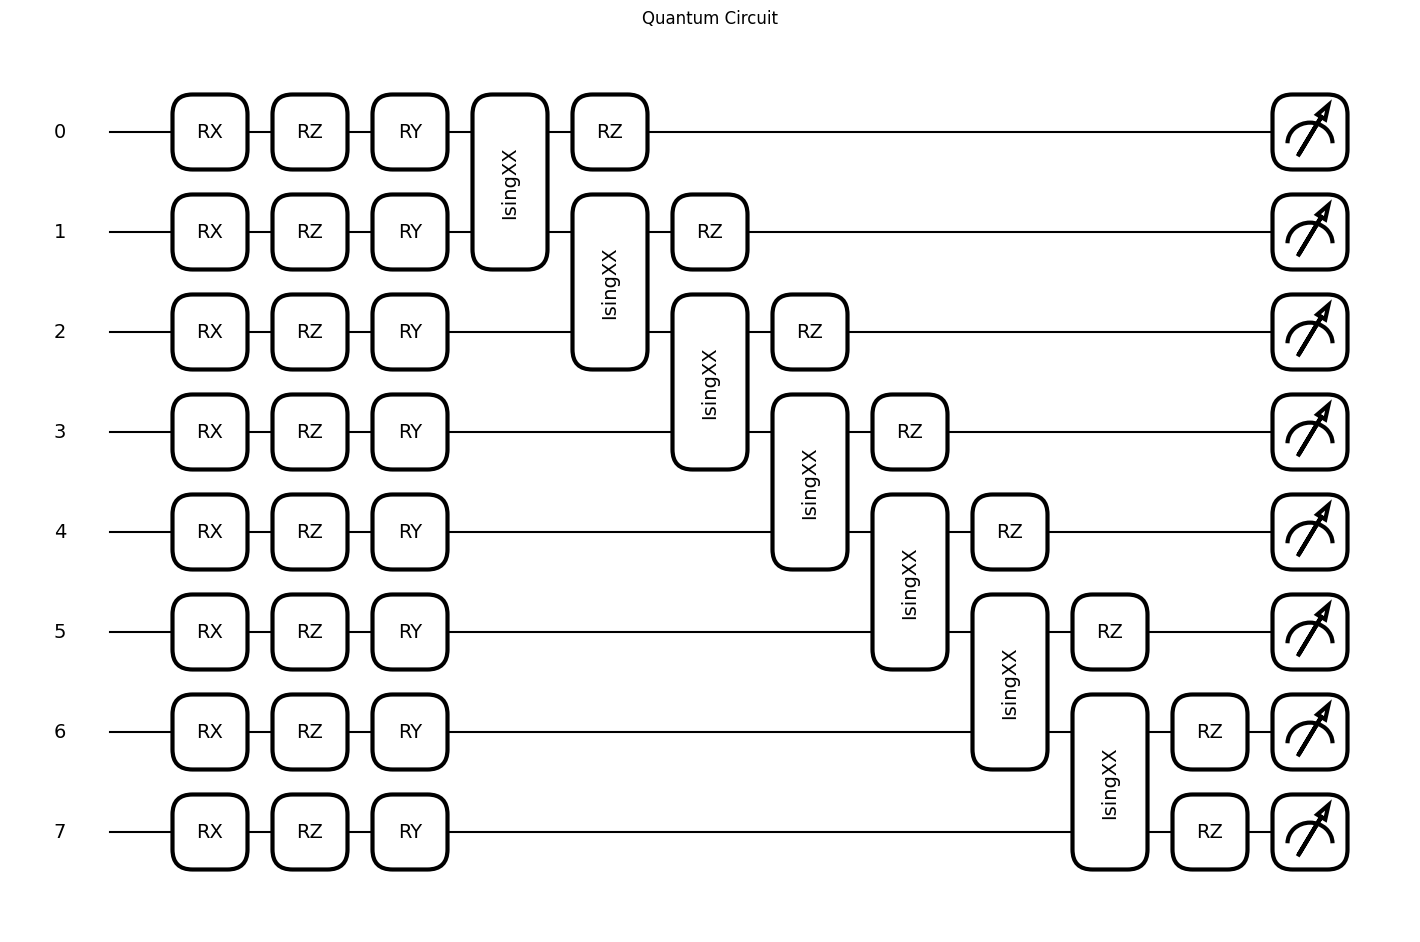

In [19]:
# 6. Draw Circuit (visualize with sample inputs)
# Get first sample and ensure proper format
sample_input = x_train[0].float()
if len(sample_input.shape) == 3:  # If image data
    sample_input = sample_input.flatten()  # Flatten to (n_features,)

# Get quantum weights (ensure they exist)
if hasattr(model, 'quantum') and hasattr(model.quantum, 'weights'):
    weights = model.quantum.weights.detach()
else:
    weights = torch.rand(3, n_qubits)  # Fallback random weights

# Draw circuit
try:
    fig, ax = qml.draw_mpl(single_circuit, expansion_strategy="device")(sample_input.numpy(), weights.numpy())
    plt.title("Quantum Circuit")
    plt.show()
except Exception as e:
    print(f"Could not draw circuit: {e}")